Image loaded successfully.


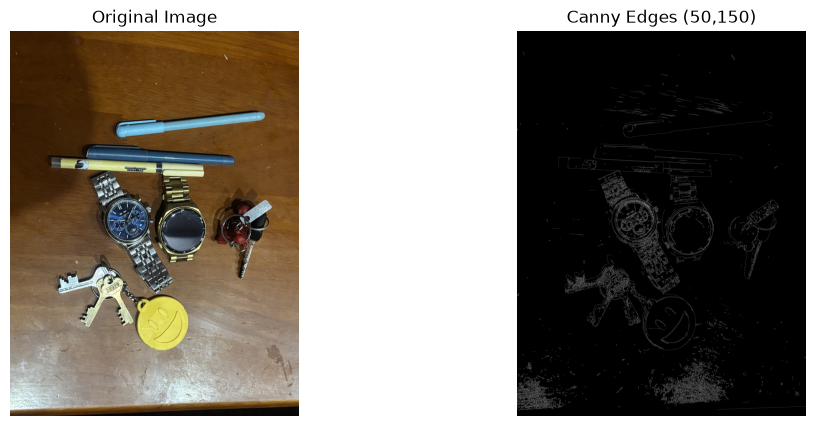

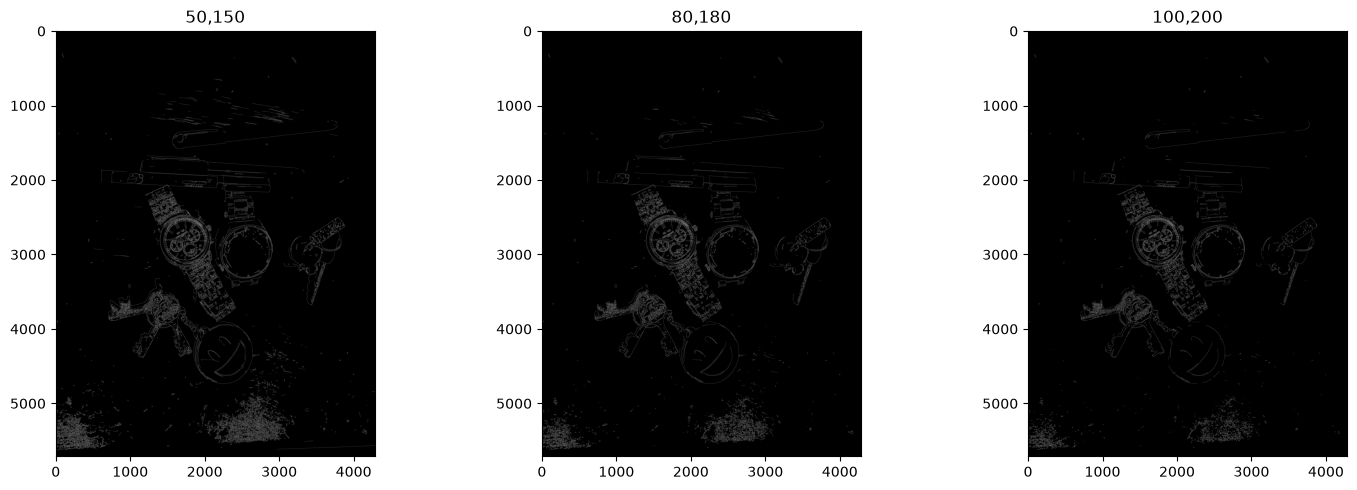

Detected Objects : 52


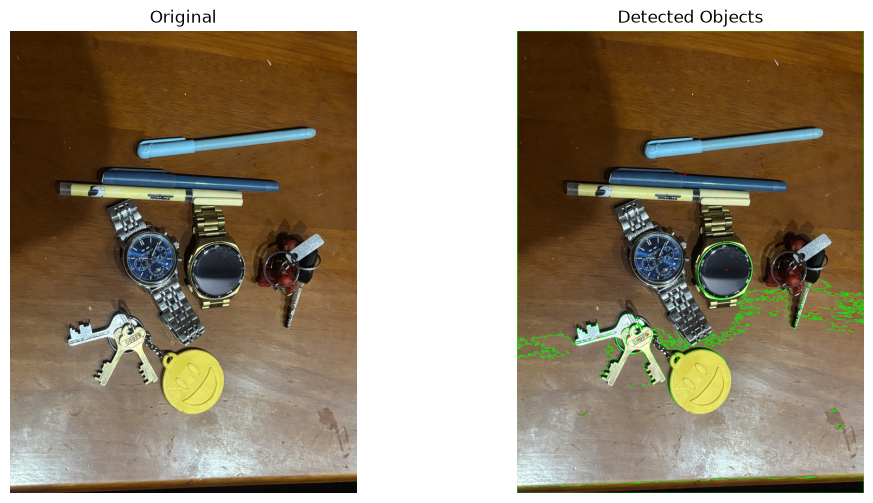

Total Objects Detected : 52


In [ ]:
# Task 5: Edge and Contour Detection

## Aim

#To detect edges using the Canny Edge Detector and count the objects present in an image using contour detection in OpenCV.

## Theory

#Edge detection identifies the boundaries of objects in an image. The Canny Edge Detector is widely used because it detects strong edges while reducing noise.

#Contours are curves joining all continuous points having the same intensity. They are useful for detecting and counting objects in an image.

import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("/Users/suriya/Documents/opencv/SuriyaKumar/raw_captures/objects.jpg")

if img is None:
    print("Image not found.")
else:
    print("Image loaded successfully.")

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 50, 150)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges (50,150)")
plt.axis("off")

plt.show()
edges2 = cv2.Canny(gray,80,180)

edges3 = cv2.Canny(gray,100,200)
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(edges,cmap="gray")
plt.title("50,150")

plt.subplot(1,3,2)
plt.imshow(edges2,cmap="gray")
plt.title("80,180")

plt.subplot(1,3,3)
plt.imshow(edges3,cmap="gray")
plt.title("100,200")

plt.tight_layout()
plt.show()
## Part A Observation

#Initially, I used thresholds of 50 and 150, but some object boundaries were incomplete.

#After trying different values, 80 and 180 produced better edges.

#It took 3 attempts to find suitable threshold values.

#The final edge image clearly highlighted all the objects present in the scene.

blur = cv2.GaussianBlur(gray,(5,5),0)

_, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)
contours, hierarchy = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
filtered_contours = []

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area > 500:
        filtered_contours.append(cnt)

print("Detected Objects :",len(filtered_contours))
output = rgb.copy()

cv2.drawContours(
    output,
    filtered_contours,
    -1,
    (0,255,0),
    3
)
for i,cnt in enumerate(filtered_contours):

    M = cv2.moments(cnt)

    if M["m00"] != 0:

        cx = int(M["m10"]/M["m00"])

        cy = int(M["m01"]/M["m00"])

        cv2.putText(
            output,
            str(i+1),
            (cx,cy),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255,0,0),
            2
        )

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(output)
plt.title("Detected Objects")

plt.axis("off")

plt.show()

print("Total Objects Detected :",len(filtered_contours))

## Part B Observation

#The contour detection algorithm initially detected **5 contours**, although only **4 objects** were present.

#A small shadow near one object was incorrectly detected as a separate contour.

#After filtering small contours based on contour area, the algorithm correctly detected all **4 objects**.

#The annotated image clearly shows the detected contours around each object.


    ## Conclusion

#The Canny Edge Detector successfully highlighted the object boundaries after selecting suitable threshold values.

#Contour detection was then used to identify and count the objects. By removing small unwanted contours, the detected object count matched the actual number of objects placed in the image

